# Introduction

**Definition:**  
    Nature-inspired meta-heuristic inspired by salp swarming, solving complex optimization problems.

**Inspiration:**  
    Salps form chains for locomotion/foraging, modeled as a leader-follower system.

**Purpose:**  
    Tackles high-dimensional search spaces where traditional methods struggle.

**Swarm Intelligence:**  
    Simple agents (salps) yield intelligent global behavior via local interactions.

<div style="text-align:center">
    <img src="./assets/salp.png" alt="flowchart for salp">
</div>

# Mathematical Modeling

**Search Space:**  
- Salps' positions in $n$-dimensional space
- Stored in two-dimensional matrix $x$
- Targeting food source $F$.

**Leader Update:**
    $$
    x_j^1 = \begin{cases}
    F_j + c_1 \left( \left(ub_j - lb_j \right)c_2 + lb_j \right) & c_3 \geq 0.5 \\
    F_j - c_1 \left( \left(ub_j - lb_j \right)c_2 + lb_j \right) & c_3 < 0.5
    \end{cases}
    $$
Where:
- $x_j^1$: Position of the leader salp in the $j$-th dimensional

- $F_j$: Position of the food source in the $j$-th dimensional

- $ub_j$: Upper bounds of the $j$-th dimension

- $lb_j$: Lower bounds of the $j$-th dimension

- $c_1 = 2\exp({-\left(\frac{4l}{L}\right)^2})$: Balances exploration/exploitation.

- $c_2, c_3 \in [0, 1]$: Random step size/direction.

Follower Update:
$$x_j^i = \frac{1}{2}(x_j^i + x_j^{i-1}), \quad i \geq 2$$

Where:
- $x_i^j$: Position of the $i$-th follower salp in the $j$-th dimension

Gradual alignment with the leader.

# Salp Swarm Algorithms

## Single-Objective SSA

**Problem:** 
$$\text{Minimize } F(\vec{x}) = f_1(\vec{x})$$
$$\text{s.t.} \quad g_{i}(\vec{x}) \geqslant 0, i = 1,2,3,...,m$$
$$\quad h_{i}(\vec{x}) = 0, i = 1,2,3,...,p$$

**Approach:**  
Food source = best solution so far; salp chain chases it.

> function SSA(n, ub, lb):  
> &emsp;&emsp;Initialize salp population $x[1], ..., x[n]$  
> &emsp;&emsp;while not end:  
> &emsp;&emsp;&emsp;&emsp;Calculate fitness of salps  
> &emsp;&emsp;&emsp;&emsp;$F$ = best salp  
> &emsp;&emsp;&emsp;&emsp;Update $c_1$  
> &emsp;&emsp;&emsp;&emsp;for $i = 1$ to $n$:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;if $i = 1$:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Update leader  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;else:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Update follower  
> &emsp;&emsp;&emsp;&emsp;Amend bounds  
> &emsp;&emsp;return $F$  

**Features:**
- Leader explores/exploits
- Followers prevent local optima.

## Multi-Objective MSSA

**Problem:**  
Minimize $F(\vec{x}) = {f_1(\vec{x}), ..., f_o(\vec{x})}$.

**Pareto Optimality:**  
Solution $\vec{x}$ dominates $\vec{y}$ if equal or better in all objectives, strictly better in one.

**Approach:**  
Repository of non-dominated solutions; food source from least crowded region.

> function MSSA(n, ub, lb):  
> &emsp;&emsp;Initialize salp population $x[1], ..., x[n]$  
> &emsp;&emsp;while not end:  
> &emsp;&emsp;&emsp;&emsp;Calculate fitness  
> &emsp;&emsp;&emsp;&emsp;Find non-dominated salps  
> &emsp;&emsp;&emsp;&emsp;Update repository  
> &emsp;&emsp;&emsp;&emsp;if repository full:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Remove crowded resident  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Add non-dominated salp  
> &emsp;&emsp;&emsp;&emsp;$F$ = least crowded solution  
> &emsp;&emsp;&emsp;&emsp;Update $c_1$  
> &emsp;&emsp;&emsp;&emsp;for $i = 1$ to $n$:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;if $i = 1$:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Update leader  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;else:  
> &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Update follower  
> &emsp;&emsp;&emsp;&emsp;Amend bounds  
> &emsp;&emsp;return repository  

Features:
- Maintains diverse Pareto front
- Avoids crowded solutions

# Properties

**Practical Applications**

- Classical Problems: Truss, beam, spring designs.
- Advanced: Airfoil (SSA), marine propeller (MSSA), Extreme Machine Learning optimization.
- Performance: Effective for specific engineering tasks; ongoing research expands applications.

**Advantages and Challenges**

- **Advantages:**
    - Handles complex problems
    - Balances exploration/exploitation
    - Avoids local optima

- **Challenges:**
    - No global optimum guarantee
    - Problem-specific performance
    - Repository complexity

**Key Takeaways**

- SSA models salp chains for optimization, with **leader-follower** dynamics.
- **SSA** for **single objectives**; **MSSA** for **multi-objectives** with **Pareto front**.
- Applications in engineering and machine learning, with problem-specific tuning

**Quick Tips**

- **Salp Chain:** Leader scouts, followers align, mimicking cooperative search.
- **Exploration/Exploitation:** $c_1$ dynamically adjusts search scope.
- **Pareto Front:** MSSA finds trade-offs for conflicting objectives.
- **Tuning Required:** Adapt SSA/MSSA to specific problems for best results.

# Codes

## Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple, Optional
import pandas as pd

## Implementation of SSO

In [4]:
class SalpSwarmOptimizer:
    """
    Implementation of Salp Swarm Algorithm (SSA)
    """
    
    def __init__(self, 
                 objective_func: Callable,
                 n_salps: int = 30,
                 max_iterations: int = 100,
                 lb: Optional[np.ndarray] = None,
                 ub: Optional[np.ndarray] = None,
                 dim: int = 2):
        """
        Initialize SSA optimizer
        
        Parameters:
        -----------
        objective_func : callable
            Objective function to minimize
        n_salps : int
            Number of salps in the swarm
        max_iterations : int
            Maximum number of iterations
        lb : np.ndarray
            Lower bounds for each dimension
        ub : np.ndarray
            Upper bounds for each dimension
        dim : int
            Problem dimensionality
        """
        self.objective_func = objective_func
        self.n_salps = n_salps
        self.max_iterations = max_iterations
        self.dim = dim
        
        # Set bounds
        if lb is None:
            self.lb = np.ones(dim) * -10
        else:
            self.lb = lb
            
        if ub is None:
            self.ub = np.ones(dim) * 10
        else:
            self.ub = ub
            
        # Initialize salp positions
        self.salps = np.random.uniform(self.lb, self.ub, (n_salps, dim))
        self.fitness = np.zeros(n_salps)
        
        # Best solution tracking
        self.best_position = None
        self.best_fitness = float('inf')
        self.convergence_history = []
        
    def evaluate_fitness(self):
        """Evaluate fitness for all salps"""
        for i in range(self.n_salps):
            self.fitness[i] = self.objective_func(self.salps[i])
            
        # Update best solution
        min_idx = np.argmin(self.fitness)
        if self.fitness[min_idx] < self.best_fitness:
            self.best_fitness = self.fitness[min_idx]
            self.best_position = self.salps[min_idx].copy()
    
    def update_leader(self, iteration: int):
        """Update the leader salp position"""
        c1 = 2 * np.exp(-(4 * iteration / self.max_iterations) ** 2)
        c2 = np.random.random()
        c3 = np.random.random() - 0.5  # Random value between -0.5 and 0.5
        
        if c3 >= 0:
            self.salps[0] = self.best_position + c1 * ((self.ub - self.lb) * c2 + self.lb)
        else:
            self.salps[0] = self.best_position - c1 * ((self.ub - self.lb) * c2 + self.lb)
    
    def update_followers(self):
        """Update follower salp positions"""
        for i in range(1, self.n_salps):
            self.salps[i] = 0.5 * (self.salps[i] + self.salps[i-1])
    
    def bound_salps(self):
        """Keep salps within bounds"""
        for i in range(self.n_salps):
            self.salps[i] = np.clip(self.salps[i], self.lb, self.ub)
    
    def optimize(self, verbose: bool = True) -> Tuple[np.ndarray, float]:
        """
        Run SSA optimization
        
        Returns:
        --------
        best_position : np.ndarray
            Best solution found
        best_fitness : float
            Best fitness value
        """
        if verbose:
            print("Starting Salp Swarm Optimization...")
            print(f"Population size: {self.n_salps}")
            print(f"Dimensions: {self.dim}")
            print(f"Max iterations: {self.max_iterations}")
            print("-" * 50)
        
        for iteration in range(self.max_iterations):
            # Evaluate fitness
            self.evaluate_fitness()
            
            # Update leader
            self.update_leader(iteration)
            
            # Update followers
            self.update_followers()
            
            # Keep salps within bounds
            self.bound_salps()
            
            # Store convergence history
            self.convergence_history.append(self.best_fitness)
            
            if verbose and (iteration + 1) % 20 == 0:
                print(f"Iteration {iteration + 1}: Best fitness = {self.best_fitness:.6f}")
        
        if verbose:
            print("-" * 50)
            print(f"Optimization completed!")
            print(f"Best position: {self.best_position}")
            print(f"Best fitness: {self.best_fitness:.6f}")
        
        return self.best_position, self.best_fitness
    
    def plot_convergence(self):
        """Plot convergence history"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.convergence_history, 'b-', linewidth=2)
        plt.title('SSA Convergence History', fontsize=14, fontweight='bold')
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('Best Fitness Value', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot_salps_2d(self, iteration: int = -1):
        """Plot salp positions in 2D (for 2D problems only)"""
        if self.dim != 2:
            print("2D plotting only available for 2-dimensional problems")
            return
            
        plt.figure(figsize=(10, 8))
        
        # Plot salp positions
        plt.scatter(self.salps[:, 0], self.salps[:, 1], 
                   c='blue', alpha=0.6, s=50, label='Salps')
        
        # Plot leader
        plt.scatter(self.salps[0, 0], self.salps[0, 1], 
                   c='red', s=100, marker='*', label='Leader')
        
        # Plot best position
        plt.scatter(self.best_position[0], self.best_position[1], 
                   c='green', s=150, marker='D', label='Best Position')
        
        # Plot bounds
        x_min, x_max = self.lb[0], self.ub[0]
        y_min, y_max = self.lb[1], self.ub[1]
        plt.plot([x_min, x_max, x_max, x_min, x_min], 
                [y_min, y_min, y_max, y_max, y_min], 'k--', alpha=0.5)
        
        plt.title(f'Salp Positions (Iteration {len(self.convergence_history)})', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('X', fontsize=12)
        plt.ylabel('Y', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Test Functions

In [5]:
# Define test functions for optimization
def sphere_function(x):
    """Sphere function - global minimum at origin"""
    return np.sum(x**2)

def rastrigin_function(x):
    """Rastrigin function - highly multimodal"""
    A = 10
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

def rosenbrock_function(x):
    """Rosenbrock function - narrow valley"""
    return np.sum(100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)

def ackley_function(x):
    """Ackley function - many local minima"""
    n = len(x)
    return (-20 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n)) - 
            np.exp(np.sum(np.cos(2 * np.pi * x)) / n) + 20 + np.e)

## Example Usage

In [6]:
# Test SSA on different functions
print("=== Testing SSA on Different Functions ===\n")

# 1. Sphere Function (2D)
print("1. Sphere Function (2D)")
sso_sphere = SalpSwarmOptimizer(
    objective_func=sphere_function,
    n_salps=30,
    max_iterations=100,
    dim=2,
    lb=np.array([-5, -5]),
    ub=np.array([5, 5])
)

best_pos, best_fit = sso_sphere.optimize(verbose=False)
print(f"Best position: {best_pos}")
print(f"Best fitness: {best_fit:.8f}")
print(f"Expected minimum: 0.0")
print()

# 2. Rastrigin Function (2D)
print("2. Rastrigin Function (2D)")
sso_rastrigin = SalpSwarmOptimizer(
    objective_func=rastrigin_function,
    n_salps=50,
    max_iterations=150,
    dim=2,
    lb=np.array([-5.12, -5.12]),
    ub=np.array([5.12, 5.12])
)

best_pos, best_fit = sso_rastrigin.optimize(verbose=False)
print(f"Best position: {best_pos}")
print(f"Best fitness: {best_fit:.8f}")
print(f"Expected minimum: 0.0")
print()

# 3. Rosenbrock Function (2D)
print("3. Rosenbrock Function (2D)")
sso_rosenbrock = SalpSwarmOptimizer(
    objective_func=rosenbrock_function,
    n_salps=40,
    max_iterations=200,
    dim=2,
    lb=np.array([-2, -2]),
    ub=np.array([2, 2])
)

best_pos, best_fit = sso_rosenbrock.optimize(verbose=False)
print(f"Best position: {best_pos}")
print(f"Best fitness: {best_fit:.8f}")
print(f"Expected minimum: 0.0 at (1, 1)")
print()

=== Testing SSA on Different Functions ===

1. Sphere Function (2D)
Best position: [ 0.04853567 -0.04841919]
Best fitness: 0.00470013
Expected minimum: 0.0

2. Rastrigin Function (2D)
Best position: [-0.97827402 -0.01664866]
Best fitness: 1.10498813
Expected minimum: 0.0

3. Rosenbrock Function (2D)
Best position: [0.87941309 0.77177825]
Best fitness: 0.01479374
Expected minimum: 0.0 at (1, 1)



## Visualization Examples

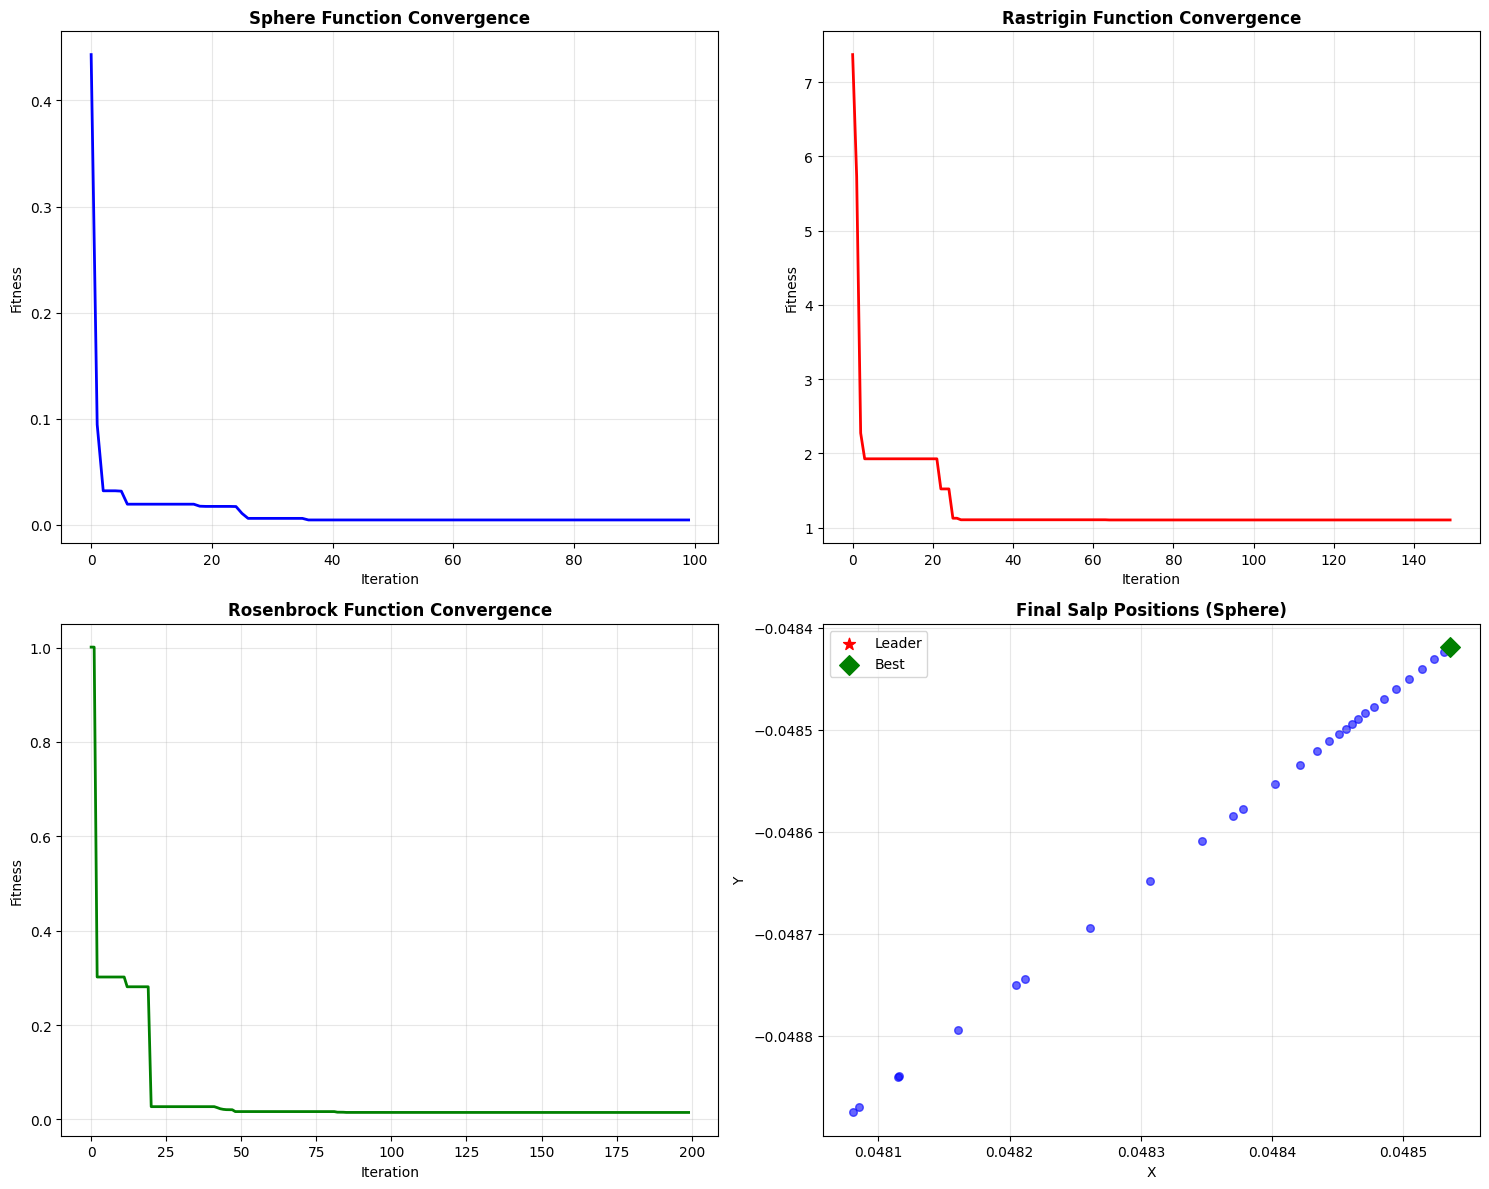

In [7]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Sphere function convergence
axes[0, 0].plot(sso_sphere.convergence_history, 'b-', linewidth=2)
axes[0, 0].set_title('Sphere Function Convergence', fontweight='bold')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Fitness')
axes[0, 0].grid(True, alpha=0.3)

# Rastrigin function convergence
axes[0, 1].plot(sso_rastrigin.convergence_history, 'r-', linewidth=2)
axes[0, 1].set_title('Rastrigin Function Convergence', fontweight='bold')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Fitness')
axes[0, 1].grid(True, alpha=0.3)

# Rosenbrock function convergence
axes[1, 0].plot(sso_rosenbrock.convergence_history, 'g-', linewidth=2)
axes[1, 0].set_title('Rosenbrock Function Convergence', fontweight='bold')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Fitness')
axes[1, 0].grid(True, alpha=0.3)

# Final salp positions for sphere function
axes[1, 1].scatter(sso_sphere.salps[:, 0], sso_sphere.salps[:, 1], 
                   c='blue', alpha=0.6, s=30)
axes[1, 1].scatter(sso_sphere.salps[0, 0], sso_sphere.salps[0, 1], 
                   c='red', s=80, marker='*', label='Leader')
axes[1, 1].scatter(sso_sphere.best_position[0], sso_sphere.best_position[1], 
                   c='green', s=100, marker='D', label='Best')
axes[1, 1].set_title('Final Salp Positions (Sphere)', fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Parameter Analysis

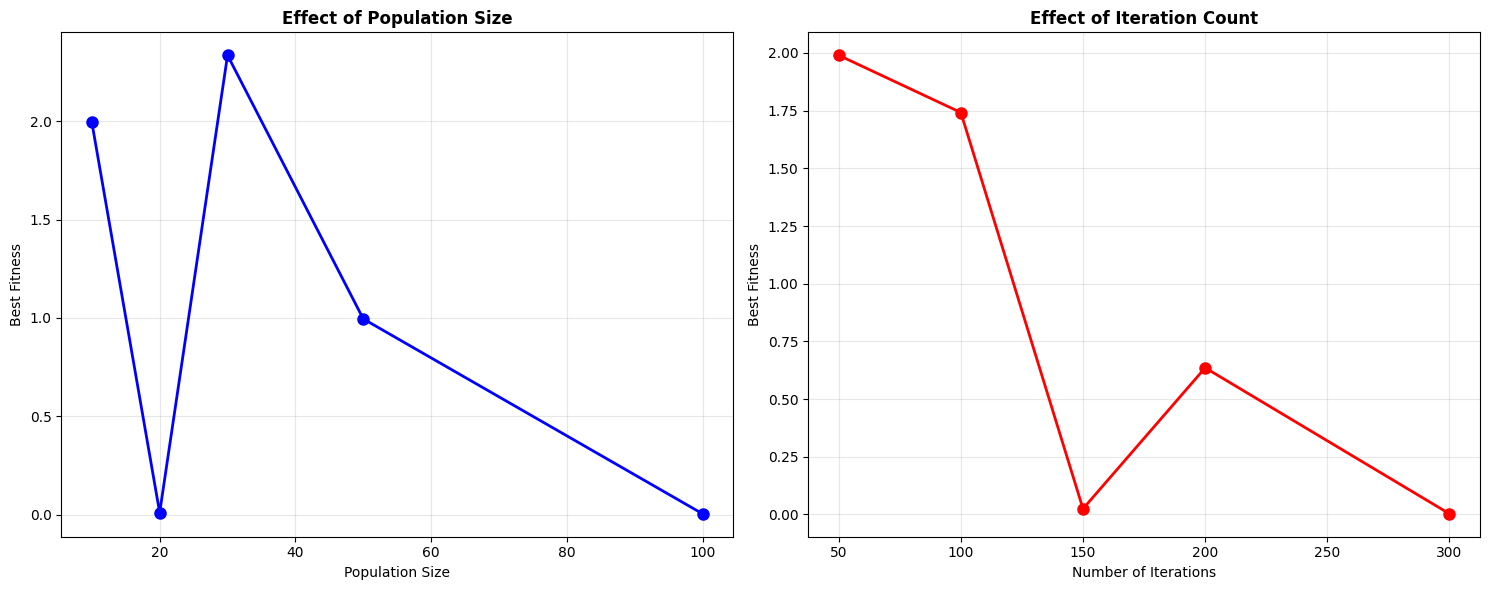

In [8]:
def parameter_analysis():
    """Analyze the effect of different parameters on SSA performance"""
    
    # Test different population sizes
    population_sizes = [10, 20, 30, 50, 100]
    results_pop = []
    
    for pop_size in population_sizes:
        sso = SalpSwarmOptimizer(
            objective_func=rastrigin_function,
            n_salps=pop_size,
            max_iterations=100,
            dim=2
        )
        _, best_fit = sso.optimize(verbose=False)
        results_pop.append(best_fit)
    
    # Test different iteration counts
    iterations = [50, 100, 150, 200, 300]
    results_iter = []
    
    for max_iter in iterations:
        sso = SalpSwarmOptimizer(
            objective_func=rastrigin_function,
            n_salps=30,
            max_iterations=max_iter,
            dim=2
        )
        _, best_fit = sso.optimize(verbose=False)
        results_iter.append(best_fit)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.plot(population_sizes, results_pop, 'bo-', linewidth=2, markersize=8)
    ax1.set_title('Effect of Population Size', fontweight='bold')
    ax1.set_xlabel('Population Size')
    ax1.set_ylabel('Best Fitness')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(iterations, results_iter, 'ro-', linewidth=2, markersize=8)
    ax2.set_title('Effect of Iteration Count', fontweight='bold')
    ax2.set_xlabel('Number of Iterations')
    ax2.set_ylabel('Best Fitness')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results_pop, results_iter

# Run parameter analysis
pop_results, iter_results = parameter_analysis()

# Reference

[Salp Swarm Algorithm](https://www.baeldung.com/cs/salp-swarm-algorithm)

Hybrid swarm optimization algorithm based on task scheduling in a cloud environment - June 2021 - International Journal of Communication Systems 